In [2]:
# All imports needed for the entire lab
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_curve, auc)
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

In [3]:
# Feature names mapped from features.md — used for Task 10 output
feature_names = [
    "having_IP_Address", "URL_Length", "Shortining_Service",
    "having_At_Symbol", "double_slash_redirecting", "Prefix_Suffix",
    "having_Sub_Domain", "SSLfinal_State", "Domain_registeration_length",
    "Favicon", "port", "HTTPS_token", "Request_URL", "URL_of_Anchor",
    "Links_in_tags", "SFH", "Submitting_to_email", "Abnormal_URL",
    "Redirect", "on_mouseover", "RightClick", "popUpWidnow", "Iframe",
    "age_of_domain", "DNSRecord", "web_traffic", "Page_Rank",
    "Google_Index", "Links_pointing_to_page", "Statistical_report"
]

In [4]:
def load_data_fold():
    """Load dataset and split using fold-based (deterministic) method — Task 3."""
    training_data = np.genfromtxt('dataset.csv', delimiter=',', dtype=np.int32)

    inputs = training_data[:, :-1]
    labels = training_data[:, -1]

    cv_fold_n = 5
    # 4 out of 5 folds = 80% for training
    training_size = (len(inputs) // cv_fold_n) * (cv_fold_n - 1)

    training_inputs = inputs[:training_size]
    training_labels = labels[:training_size]
    testing_inputs  = inputs[training_size:]
    testing_labels  = labels[training_size:]

    return training_inputs, testing_inputs, training_labels, testing_labels

# Run it
train_in, test_in, train_lbl, test_lbl = load_data_fold()
print(f"Training samples : {len(train_in)}")
print(f"Testing  samples : {len(test_in)}")

Training samples : 8844
Testing  samples : 2211


In [5]:
# Train Decision Tree on fold-based split
dt_classifier = tree.DecisionTreeClassifier()
dt_classifier.fit(train_in, train_lbl)
dt_predictions = dt_classifier.predict(test_in)

dt_accuracy = 100.0 * accuracy_score(test_lbl, dt_predictions)
print(f"Decision Tree accuracy (fold split): {dt_accuracy:.2f}%")

Decision Tree accuracy (fold split): 89.73%


In [6]:
# Extended metrics for Decision Tree (fold-based split)
dt_precision = 100.0 * precision_score(test_lbl, dt_predictions)
dt_recall    = 100.0 * recall_score(test_lbl, dt_predictions)
dt_f1        = 100.0 * f1_score(test_lbl, dt_predictions)

print(f"Precision : {dt_precision:.2f}%")
print(f"Recall    : {dt_recall:.2f}%")
print(f"F1-Score  : {dt_f1:.2f}%")

Precision : 92.04%
Recall    : 89.27%
F1-Score  : 90.63%


In [7]:
def load_data_random():
    """Load dataset and split randomly using train_test_split — Task 6."""
    training_data = np.genfromtxt('dataset.csv', delimiter=',', dtype=np.int32)
    inputs = training_data[:, :-1]
    labels = training_data[:, -1]

    training_inputs, testing_inputs, training_labels, testing_labels = train_test_split(
        inputs, labels, train_size=0.8, random_state=40
    )
    return training_inputs, testing_inputs, training_labels, testing_labels

# Run random split
r_train_in, r_test_in, r_train_lbl, r_test_lbl = load_data_random()

# Retrain Decision Tree on random split
dt_r = tree.DecisionTreeClassifier()
dt_r.fit(r_train_in, r_train_lbl)
dt_r_preds = dt_r.predict(r_test_in)

dt_r_acc  = 100.0 * accuracy_score(r_test_lbl, dt_r_preds)
dt_r_prec = 100.0 * precision_score(r_test_lbl, dt_r_preds)
dt_r_rec  = 100.0 * recall_score(r_test_lbl, dt_r_preds)
dt_r_f1   = 100.0 * f1_score(r_test_lbl, dt_r_preds)

print("--- Decision Tree: Fold Split vs Random Split ---")
print(f"{'Metric':<12} {'Fold Split':>12} {'Random Split':>14}")
print(f"{'Accuracy':<12} {dt_accuracy:>11.2f}% {dt_r_acc:>13.2f}%")
print(f"{'Precision':<12} {dt_precision:>11.2f}% {dt_r_prec:>13.2f}%")
print(f"{'Recall':<12} {dt_recall:>11.2f}% {dt_r_rec:>13.2f}%")
print(f"{'F1-Score':<12} {dt_f1:>11.2f}% {dt_r_f1:>13.2f}%")

--- Decision Tree: Fold Split vs Random Split ---
Metric         Fold Split   Random Split
Accuracy           89.73%         95.57%
Precision          92.04%         96.06%
Recall             89.27%         96.06%
F1-Score           90.63%         96.06%


In [8]:
# Train Random Forest on random split
rf_classifier = RandomForestClassifier(random_state=40)
rf_classifier.fit(r_train_in, r_train_lbl)
rf_predictions = rf_classifier.predict(r_test_in)

rf_acc  = 100.0 * accuracy_score(r_test_lbl, rf_predictions)
rf_prec = 100.0 * precision_score(r_test_lbl, rf_predictions)
rf_rec  = 100.0 * recall_score(r_test_lbl, rf_predictions)
rf_f1   = 100.0 * f1_score(r_test_lbl, rf_predictions)

print("--- Decision Tree vs Random Forest (random split) ---")
print(f"{'Metric':<12} {'Decision Tree':>15} {'Random Forest':>15}")
print(f"{'Accuracy':<12} {dt_r_acc:>14.2f}% {rf_acc:>14.2f}%")
print(f"{'Precision':<12} {dt_r_prec:>14.2f}% {rf_prec:>14.2f}%")
print(f"{'Recall':<12} {dt_r_rec:>14.2f}% {rf_rec:>14.2f}%")
print(f"{'F1-Score':<12} {dt_r_f1:>14.2f}% {rf_f1:>14.2f}%")

--- Decision Tree vs Random Forest (random split) ---
Metric         Decision Tree   Random Forest
Accuracy              95.57%          96.92%
Precision             96.06%          96.82%
Recall                96.06%          97.75%
F1-Score              96.06%          97.28%


Decision Tree AUC : 0.9669
Random Forest AUC : 0.9949


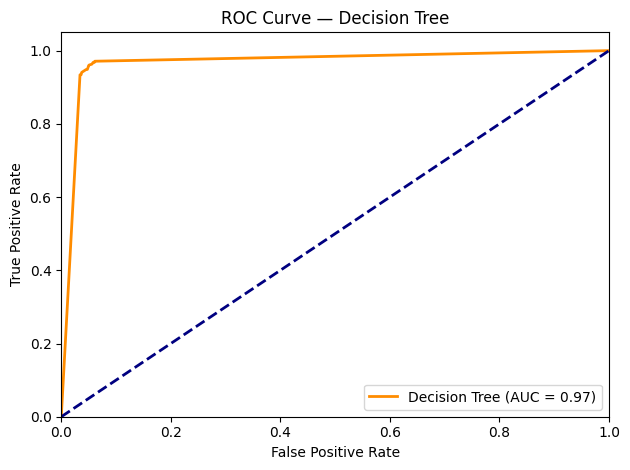

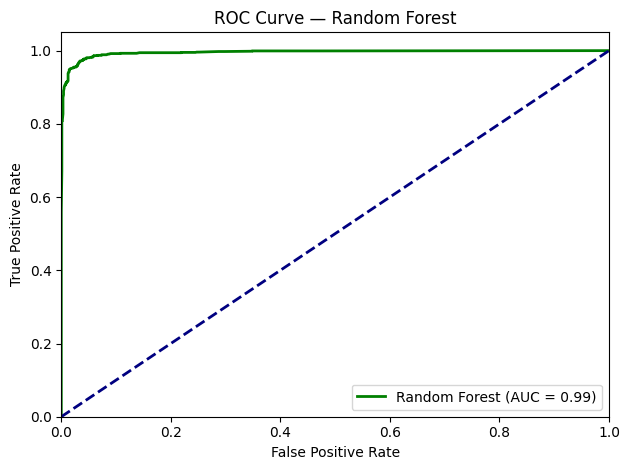

In [9]:
# Get predicted probabilities for positive class
dt_probs = dt_r.predict_proba(r_test_in)[:, 1]
rf_probs = rf_classifier.predict_proba(r_test_in)[:, 1]

# Compute ROC curves
dt_fpr, dt_tpr, _ = roc_curve(r_test_lbl, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(r_test_lbl, rf_probs)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

print(f"Decision Tree AUC : {dt_auc:.4f}")
print(f"Random Forest AUC : {rf_auc:.4f}")

# Plot Decision Tree ROC
plt.figure()
plt.plot(dt_fpr, dt_tpr, color='darkorange', lw=2,
         label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Decision Tree')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_decision_tree.png', dpi=150)
plt.show()

# Plot Random Forest ROC
plt.figure()
plt.plot(rf_fpr, rf_tpr, color='green', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_random_forest.png', dpi=150)
plt.show()

In [10]:
# Evaluate Random Forest at different thresholds
thresholds = [0.4, 0.5, 0.6, 0.7]

print(f"{'Threshold':<12} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}")
print("-" * 55)

for t in thresholds:
    custom_preds = np.where(rf_probs >= t, 1, -1)
    acc  = 100.0 * accuracy_score(r_test_lbl, custom_preds)
    prec = 100.0 * precision_score(r_test_lbl, custom_preds, zero_division=0)
    rec  = 100.0 * recall_score(r_test_lbl, custom_preds, zero_division=0)
    f1   = 100.0 * f1_score(r_test_lbl, custom_preds, zero_division=0)
    print(f"{t:<12} {acc:>9.2f}% {prec:>10.2f}% {rec:>7.2f}% {f1:>7.2f}%")

Threshold      Accuracy   Precision   Recall       F1
-------------------------------------------------------
0.4              96.47%      95.62%   98.23%   96.91%
0.5              96.88%      96.74%   97.75%   97.24%
0.6              96.83%      97.19%   97.19%   97.19%
0.7              96.43%      97.71%   95.90%   96.80%


In [11]:
# Extract and rank feature importances
dt_importances = dt_r.feature_importances_
rf_importances = rf_classifier.feature_importances_

dt_sorted = np.argsort(dt_importances)[::-1]
rf_sorted = np.argsort(rf_importances)[::-1]

print("Top 5 features — Decision Tree:")
for i in range(5):
    idx = dt_sorted[i]
    print(f"  {i+1}. {feature_names[idx]:<35} importance: {dt_importances[idx]:.4f}")

print("\nTop 5 features — Random Forest:")
for i in range(5):
    idx = rf_sorted[i]
    print(f"  {i+1}. {feature_names[idx]:<35} importance: {rf_importances[idx]:.4f}")

Top 5 features — Decision Tree:
  1. SSLfinal_State                      importance: 0.6170
  2. URL_of_Anchor                       importance: 0.1144
  3. Links_in_tags                       importance: 0.0383
  4. web_traffic                         importance: 0.0335
  5. having_Sub_Domain                   importance: 0.0290

Top 5 features — Random Forest:
  1. SSLfinal_State                      importance: 0.3234
  2. URL_of_Anchor                       importance: 0.2412
  3. web_traffic                         importance: 0.0741
  4. having_Sub_Domain                   importance: 0.0614
  5. Prefix_Suffix                       importance: 0.0452


In [12]:
from sklearn.model_selection import KFold

training_data = np.genfromtxt('dataset.csv', delimiter=',', dtype=np.int32)
all_inputs = training_data[:, :-1]
all_labels = training_data[:, -1]

kf = KFold(n_splits=5, shuffle=True, random_state=40)
fold_results = []

print(f"{'Fold':<6} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}")
print("-" * 48)

for fold, (train_idx, test_idx) in enumerate(kf.split(all_inputs), 1):
    X_tr, X_te = all_inputs[train_idx], all_inputs[test_idx]
    y_tr, y_te = all_labels[train_idx], all_labels[test_idx]

    clf = tree.DecisionTreeClassifier()
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)

    acc  = 100.0 * accuracy_score(y_te, preds)
    prec = 100.0 * precision_score(y_te, preds)
    rec  = 100.0 * recall_score(y_te, preds)
    f1   = 100.0 * f1_score(y_te, preds)
    fold_results.append((acc, prec, rec, f1))
    print(f"{fold:<6} {acc:>9.2f}% {prec:>10.2f}% {rec:>7.2f}% {f1:>7.2f}%")

fold_results = np.array(fold_results)
print("-" * 48)
print(f"{'Mean':<6} {fold_results[:,0].mean():>9.2f}% {fold_results[:,1].mean():>10.2f}% "
      f"{fold_results[:,2].mean():>7.2f}% {fold_results[:,3].mean():>7.2f}%")
print(f"{'Std':<6} {fold_results[:,0].std():>9.2f}% {fold_results[:,1].std():>10.2f}% "
      f"{fold_results[:,2].std():>7.2f}% {fold_results[:,3].std():>7.2f}%")

Fold     Accuracy   Precision   Recall       F1
------------------------------------------------
1          95.57%      96.06%   96.06%   96.06%
2          96.61%      96.56%   97.28%   96.92%
3          96.61%      97.05%   96.81%   96.93%
4          95.93%      96.24%   96.40%   96.32%
5          96.74%      96.54%   97.77%   97.15%
------------------------------------------------
Mean       96.29%      96.49%   96.86%   96.68%
Std         0.46%       0.34%    0.61%    0.41%


In [13]:
# Dummy baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(r_train_in, r_train_lbl)
dummy_preds = dummy.predict(r_test_in)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=40)
lr.fit(r_train_in, r_train_lbl)
lr_preds = lr.predict(r_test_in)

for name, preds in [("DummyClassifier", dummy_preds), ("Logistic Regression", lr_preds)]:
    acc  = 100.0 * accuracy_score(r_test_lbl, preds)
    prec = 100.0 * precision_score(r_test_lbl, preds, zero_division=0)
    rec  = 100.0 * recall_score(r_test_lbl, preds, zero_division=0)
    f1   = 100.0 * f1_score(r_test_lbl, preds, zero_division=0)
    print(f"{name}: Acc={acc:.2f}% Prec={prec:.2f}% Rec={rec:.2f}% F1={f1:.2f}%")

DummyClassifier: Acc=56.26% Prec=56.26% Rec=100.00% F1=72.01%
Logistic Regression: Acc=92.54% Prec=92.85% Rec=93.97% F1=93.41%


In [14]:
# Compare training vs testing accuracy to check for overfitting
train_preds = dt_r.predict(r_train_in)
train_acc = 100.0 * accuracy_score(r_train_lbl, train_preds)
test_acc  = 100.0 * accuracy_score(r_test_lbl,  dt_r_preds)

print(f"Decision Tree training accuracy : {train_acc:.2f}%")
print(f"Decision Tree testing  accuracy : {test_acc:.2f}%")
print(f"Overfitting gap                 : {train_acc - test_acc:.2f}%")

Decision Tree training accuracy : 99.08%
Decision Tree testing  accuracy : 95.57%
Overfitting gap                 : 3.52%
